In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import StrMethodFormatter,PercentFormatter
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
#Create DACH data frame

DACH_countries = ["Germany","Austria","Switzerland","Luxembourg"]

df_DACH = df[df["job_country"].isin(DACH_countries)].copy()

In [3]:
#Create numerical column for months

df_DACH["job_posted_month"] = df_DACH["job_posted_date"].dt.month

In [4]:
#Expand/Explode list job_skills into seperate rows

df_DACH_expl = df_DACH.explode(column="job_skills")

In [5]:
#Pivot exploded DF to display size/count of each skill by month (null values are set to 0)

df_DACH_pivot = df_DACH_expl.pivot_table(index="job_posted_month",columns="job_skills",aggfunc="size",fill_value=0)

In [6]:
#Create new row with sums of each skill count (for sorting purposes)

df_DACH_pivot.loc["total"]=df_DACH_pivot.sum()

In [7]:
#Sort columns (skills) by row "total" (full count of each skill in the entire year)

df_DACH_pivot = df_DACH_pivot[df_DACH_pivot.loc["total"].sort_values(ascending=False).index]

In [8]:
#Remove row "total". Otherwise it would screw up the data visualization

df_DACH_pivot.drop(index="total",inplace=True)

In [9]:
#Create series with number of postings grouped by month

DACH_countbymonth = df_DACH.groupby("job_posted_month").size()

In [10]:
#Calculate df with column for prominence of each skill by month (in %)

df_DACH_perc = df_DACH_pivot.div(DACH_countbymonth/100,axis=0)

In [11]:
#Change month display type from integer to short month name as a string

df_DACH_perc.reset_index(names="jobs_by_month",inplace=True)

df_DACH_perc["job_posted_month"] = df_DACH_perc["jobs_by_month"].apply(lambda x: pd.to_datetime(x,format="%m").strftime("%b"))

df_DACH_perc.set_index("job_posted_month",inplace=True)

df_DACH_perc.drop(columns="jobs_by_month",inplace=True)

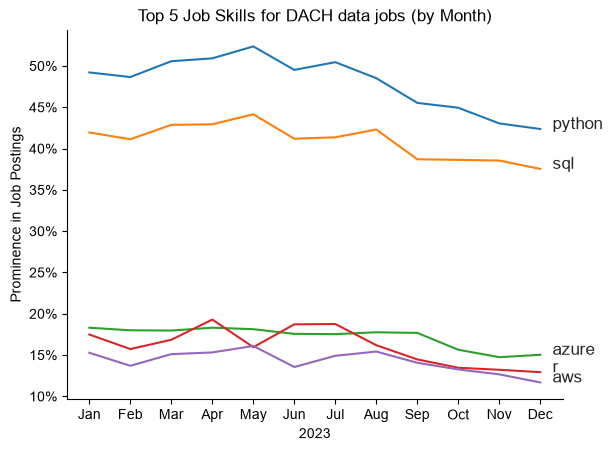

In [12]:
#Visualize the final result as a line plot

df_DACH_plot = df_DACH_perc.iloc[:,:5]

sns.lineplot(data=df_DACH_plot,dashes=False,palette="tab10")
sns.set_theme(style="ticks")

plt.title("Top 5 Job Skills for DACH data jobs (by Month)")
plt.ylabel("Prominence in Job Postings")
plt.xlabel("2023")
plt.legend().remove()
sns.despine()

for i in range(5):
    plt.text(11.3,df_DACH_plot.iloc[-1,i],df_DACH_plot.columns[i])

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()